# DocAna Project '26 
## Topic Lost or Found? 
### Measuring Topic Fidelity in Reddit TL;DR Summaries

Project of the class Document Analysis taught by JProf. Andreas Spitz

*Submitted by: Ekaterina Kabashko (Student-ID: 1474411) / Anastasia Siebers (Student-ID: 1498118)*

## Import Packages & Data

In [1]:
#Import Chunk 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import statsmodels.formula.api as smf

import os
from pathlib import Path

import nltk
from nltk.corpus import stopwords

import pickle
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN


In [2]:
#Load the data

#Set the base path to the current working directory
base_path = Path.cwd()

#Search for the file recursively in order to import it
preprocessed_data_file_path = next(base_path.rglob("selected_4_subreddits_1000_each_clean_lda.csv"))

#Import the data and create a dataframe
df_data = pd.read_csv(preprocessed_data_file_path)

In [3]:
df_data.head()

,author,body,normalizedBody,subreddit,subreddit_id,id,content,summary,content_clean,summary_clean,content_lda_preprocessed,summary_lda_preprocessed
0,Aintsley,I don't know where you access your information...,I don't know where you access your information...,explainlikeimfive,t5_2sokd,ckxy36n,I don't know where you access your information...,about 4% for the (65) age group develop ... \n...,I don't know where you access your information...,about 4% for the (65) age group develop ... gr...,know access information claiming male develop ...,age group develop gradually range
1,Jiveturkeey,Some Americans are obsessed with guns. Many of...,Some Americans are obsessed with guns. Many of...,explainlikeimfive,t5_2sokd,ce72xym,Some Americans are obsessed with guns. Many of...,Guns are part of American culture due to our r...,Some Americans are obsessed with guns. Many of...,Guns are part of American culture due to our r...,american obsessed gun many member nra make lot...,gun part american culture due revolutionary be...
2,JimMarch,The reason Solzhenitsyn was thrown out of the ...,The reason Solzhenitsyn was thrown out of the ...,explainlikeimfive,t5_2sokd,cl9u78u,The reason Solzhenitsyn was thrown out of the ...,I have no use for communist apologetics.,The reason Solzhenitsyn was thrown out of the ...,I have no use for communist apologetics.,reason solzhenitsyn thrown ussr breshnev era t...,use communist apologetics
3,MyNameIsRay,"There are some exceptions. Trader Joe's wine, ...","There are some exceptions. Trader Joe's wine, ...",explainlikeimfive,t5_2sokd,coodnvc,"There are some exceptions. Trader Joe's wine, ...","cheap can be the way it's supposed to be, if y...","There are some exceptions. Trader Joe's wine, ...","cheap can be the way it's supposed to be, if y...",exception trader joe wine two buck chuck calle...,cheap way supposed know look expensive guarant...
4,Lorikeet,Interesting.. But how enforced is this? About ...,Interesting.. But how enforced is this? About ...,explainlikeimfive,t5_2sokd,ce8uqrb,Interesting.. But how enforced is this? About ...,"don't fly United, ever.",Interesting.. But how enforced is this? About ...,"don't fly United, ever.",interesting enforced two year ago told flight ...,fly united ever


## Run LDA topic modeling

In [4]:
### LDA ESTIMATION

#We train the dictionary and the LDA model on content
#Then we apply it to both - content and summary
#This way both live in the same 100-topic space

# Set a random seed for replication
np.random.seed(265) 

# Estimate the topics 
list_data_content = []
for i in range(0,len(df_data.content_lda_preprocessed)):
    list_data_content.append(df_data.content_lda_preprocessed.iloc[i].split())
    
len(list_data_content) 

id2word_content = corpora.Dictionary(list_data_content)

# all words that appear less than 20 times in the corpus are removed from the vocabulary
id2word_content.filter_extremes(no_below=20, no_above=1.0, keep_n=None)

# Korpus
texts_content = list_data_content

# Term Document Frequency
corpus_content = [id2word_content.doc2bow(text) for text in texts_content]

# training lda model
lda_model_50_content = gensim.models.ldamodel.LdaModel(corpus=corpus_content,
                                           id2word=id2word_content,
                                           num_topics= 50, 
                                           random_state=100,
                                           update_every=10,
                                           chunksize=10000,
                                           passes=10,
                                           alpha='auto',
                                           per_word_topics=True)

#### EXTRACT TOPIC WEIGHTS 

# Extract topic weights from LDA model - content
topic_dist_lda_content = lda_model_50_content.get_document_topics(
    corpus_content,
    minimum_probability=0
)

topicweights_content = []

for i in range(0, len(topic_dist_lda_content)):
    topicweights_content.append(topic_dist_lda_content[i])

dct_content = [dict(topicweights_content[i]) for i in range(0, len(topicweights_content))]

df_content = pd.DataFrame.from_dict(dct_content)

cols_content = df_content.columns.tolist()
cols_content.sort()

df_topicweights_content = df_content[cols_content]
df_topicweights_content = df_topicweights_content.fillna(0)

#Save Topicweights for replication
df_topicweights_content.to_csv("LDA_50_Topic_Weights/lda_topicweights_content.csv")

#Add the topic vectors to the data dataframe
df_data["lda_content_topic_vec"] = df_topicweights_content.to_numpy().tolist()

In [5]:
#Check if all summaries survived the pre-processing
df_data.summary_lda_preprocessed.isna().sum()


np.int64(25)

In [6]:
# We have to use a mask since summary has 25 missing values after pre-processing
# Just dropping them doesn't make sense since it is a useful information that they are missing after pre-processing
# If they are missing that means they didn't match the content
valid_summary_mask = df_data["summary_lda_preprocessed"].notna()
df_data_valid_summary = df_data[valid_summary_mask]

list_data_summary = []
for i in range(0,len(df_data_valid_summary.summary_lda_preprocessed)):
    list_data_summary.append(df_data_valid_summary.summary_lda_preprocessed.iloc[i].split())

corpus_summary = [
    id2word_content.doc2bow(text)
    for text in list_data_summary
]

topic_dist_lda_summary = lda_model_50_content.get_document_topics(
    corpus_summary,
    minimum_probability=0
)

topicweights_summary = []

for i in range(0, len(topic_dist_lda_summary)):
    topicweights_summary.append(topic_dist_lda_summary[i])

dct_summary = [dict(topicweights_summary[i]) for i in range(0, len(topicweights_summary))]

df_summary = pd.DataFrame.from_dict(dct_summary)

cols_summary = df_summary.columns.tolist()
cols_summary.sort()

df_topicweights_summary = df_summary[cols_summary]
df_topicweights_summary = df_topicweights_summary.fillna(0)

#Save Topicweights for replication
df_topicweights_summary.to_csv("LDA_50_Topic_Weights/lda_topicweights_summary.csv")

df_data["summary_topic_vec"] = None

#Make sure that everything is mapped correctly 
df_data.loc[valid_summary_mask, "summary_topic_vec"] = pd.Series(
    df_topicweights_summary.to_numpy().tolist(),
    index=df_data_valid_summary.index
)

In [7]:
#Calculate cosine similarity to get a matching score 
#Use a mask again because of the 25 entries without a summary and thereby without a vector
has_summary_vec = df_data["summary_topic_vec"].apply(lambda x: isinstance(x, list))

df_data["cosine_similarity_lda"] = 0.0

df_data.loc[has_summary_vec, "cosine_similarity_lda"] = [
    cosine_similarity([content_vec], [summary_vec])[0, 0]
    for content_vec, summary_vec in zip(
        df_data.loc[has_summary_vec, "lda_content_topic_vec"],
        df_data.loc[has_summary_vec, "summary_topic_vec"]
    )
]

In [8]:
# Look at a few topics to get an impression of the topics 
topic_overview = []

for topic_id in range(50):
    top_words = lda_model_50_content.show_topic(topic_id, topn=20)

    topic_overview.append({
        "topic_id": topic_id,
        "top_words": " ".join([word for word, weight in top_words])
    })

df_topic_overview = pd.DataFrame(topic_overview)

print(df_topic_overview.to_string(index=False))

 topic_id                                                                                                                                  top_words
        0                       language like word even people english point also mean think really time example thing use voice still one made good
        1                              people job one year risk know work also want solid fact get study even problem dream maybe starting white way
        2                         woman human animal muscle body also energy nuclear thing male like much brain level one would stress get study new
        3     black white crime group person get community news people one population victim like say fact change statistic memory someone committed
        4                                      car like get would people going feel way lot well see back say make know thing one much driving still
        5                                     people time like would food really lot one get even care mad

## Run BERT topic modeling

In [9]:
# One element = one full speech
content = df_data["content_clean"].tolist()
summary = df_data["summary_clean"].tolist()

#### Deal with stop-words in text clean
nltk.download("stopwords")
english_stopwords = stopwords.words("english")


# Vectorizer for BERTopic topic-word representations
vectorizer_model = CountVectorizer(
    stop_words=english_stopwords ,
    min_df=2,
    ngram_range=(1, 2)
)

#### Apply BERTopic Model

# Use the default english sentence embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Make dimensionality reduction and clustering reproducible/tunable
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=265
)

hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# Initialize BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities = True,
    verbose=True
)

# Fit topic model and assign topics and probabilites to content
topics_content, probabilities_content = topic_model.fit_transform(content)

# Fit the topic model and assign topics and probabilities to summary - infer summary vectors in the same topic space as content
topics_summary, probabilities_summary = topic_model.transform(summary) 

# Store assigned BERTopic topic for each speech
df_data["BERTopic_content_topic_vec"] = probabilities_content.tolist()
df_data["BERTopic_content_summary_vec"] = probabilities_summary.tolist()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/anastasiasiebers/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-06-30 10:48:09,128 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

2026-06-30 10:48:38,279 - BERTopic - Embedding - Completed ✓
2026-06-30 10:48:38,279 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-30 10:48:54,719 - BERTopic - Dimensionality - Completed ✓
2026-06-30 10:48:54,720 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-30 10:48:54,887 - BERTopic - Cluster - Completed ✓
2026-06-30 10:48:54,890 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-30 10:48:55,375 - BERTopic - Representation - Completed ✓


Batches:   0%|          | 0/125 [00:00<?, ?it/s]

2026-06-30 10:49:05,594 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-06-30 10:49:23,361 - BERTopic - Dimensionality - Completed ✓
2026-06-30 10:49:23,361 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-06-30 10:49:23,402 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-06-30 10:49:23,580 - BERTopic - Probabilities - Completed ✓
2026-06-30 10:49:23,580 - BERTopic - Cluster - Completed ✓


In [10]:
df_data["cosine_similarity_BERTopic"] = df_data.apply(
    lambda row: cosine_similarity(
        [row["BERTopic_content_topic_vec"]],
        [row["BERTopic_content_summary_vec"]]
    )[0, 0],
    axis=1
)

In [29]:
# Look at top 10 topics
topic_overview = topic_model.get_topic_info()

print(
    topic_overview[
        ["Topic", "Representation"]
    ]
    .to_string(index=False)[:1300]
)

 Topic                                                                               Representation
    -1                                  [people, would, one, like, get, time, even, make, also, us]
     0                                 [game, games, play, like, one, get, time, really, pc, would]
     1               [people, tax, government, money, pay, would, income, insurance, taxes, health]
     2                  [people, like, news, reddit, know, information, science, would, think, one]
     3                                  [brain, sleep, body, time, get, like, skin, back, day, one]
     4                        [women, men, sex, people, woman, male, female, gay, abortion, gender]
     5    [school, students, college, education, student, schools, university, job, teachers, year]
     6    [party, vote, obama, people, political, government, voting, candidate, would, republican]
     7                  [war, us, nuclear, germany, japan, would, military, japanese, israel, iran]


In [12]:
#Print the number of total topics and the classified outliers in content and summary
total_topics = (
    topic_model.get_topic_info()["Topic"]
    .ne(-1)
    .sum()
)

content_outliers = np.sum(np.asarray(topics_content) == -1)
summary_outliers = np.sum(np.asarray(topics_summary) == -1)

print("Total number of BERTopic topics:", total_topics)

print(
    f"Content outliers: {content_outliers} "
    f"({content_outliers / len(topics_content) * 100:.2f}%)"
)

print(
    f"Summary outliers: {summary_outliers} "
    f"({summary_outliers / len(topics_summary) * 100:.2f}%)"
)

Total number of BERTopic topics: 20
Content outliers: 953 (23.82%)
Summary outliers: 1707 (42.68%)


## Look at some Examples with high and low similiarity 

In [13]:
#Since we want to print four different cases we decided to write a function 
def print_random_examples(data, score_column, title, n=5, random_state=265):
    """
    Print a random sample of content-summary pairs and their similarity scores

    Input: - data: DataFrame containing the examples
           - score_column: Name of the similarity-score column
           - title: Title printed above the examples
           - n: Number of examples to print
           - random_state: Seed used for reproducible sampling
    """
    print(f"\n{'=' * 20} {title} {'=' * 20}")

    examples = data.sample(n=n, random_state=random_state)

    for number, (_, row) in enumerate(examples.iterrows(), start=1):
        print(f"\nExample {number}")
        print(f"Similarity: {row[score_column]:.4f}")
        print(f"Content:\n{row['content']}")
        print(f"\nSummary:\n{row['summary']}")
        print("-" * 80)

In [14]:
# High Similarity - LDA
valid_lda = df_data[
    df_data["summary_topic_vec"].apply(
        lambda value: isinstance(value, (list, np.ndarray))
    )
].copy()

lda_high_cutoff = valid_lda["cosine_similarity_lda"].quantile(0.75)
lda_high = valid_lda[
    valid_lda["cosine_similarity_lda"] >= lda_high_cutoff
]

print_random_examples(
    lda_high,
    "cosine_similarity_lda",
    f"LDA high similarity (≥ {lda_high_cutoff:.4f})"
)


==================== LDA high similarity (≥ 0.5588) ====================

Example 1
Similarity: 0.9673
Content:
Producers are in charge of getting a movie made in the most practical sense. They need to be sure that the is money, that there are professionals to help actually act/film the movie. They are also in charge of making sure that the movie makes money and is successful. Different producers and production companies might be more concerned with making a lot of money than others, but they all want to at least make their money back. Because of this, producers can sometimes make decisions about what goes in the movie based on what they think will sell tickets, avoid upsetting people, or get people excited to see a sequel. 
 The director is in charge of making the story written by the writers into a film. They try to tell the actors how to deliver the lines so the viewer believes what's going on. They decide how to set up the scenery and the cameras so the viewer feels connected to w

In [15]:
# Low Similarity - LDA
lda_low_cutoff = valid_lda["cosine_similarity_lda"].quantile(0.25)
lda_low = valid_lda[
    valid_lda["cosine_similarity_lda"] <= lda_low_cutoff
]

print_random_examples(
    lda_low,
    "cosine_similarity_lda",
    f"LDA low similarity (≤ {lda_low_cutoff:.4f})"
)


==================== LDA low similarity (≤ 0.0095) ====================

Example 1
Similarity: 0.0057
Content:
Number theorist here. Not sure why this is so highly voted. You simply explained RSA here, which really has absolutely nothing to do with the ABC conjecture. Simply put, a proof of the ABC conjecture has absolutely no profound effect on the average person's life, as mathematicians have believed it to be true for a long time. Moreover, to my knowledge there are no algorithms whose complexity are provably dependent on the ABC conjecture. This differs from things like the Generalized Riemann Hypothesis, for instance, as fast algorithms for finding a primitive root modulo large primes is dependent on GRH being true. Since mathematicians assume it to be true, the algorithms are written assuming that it is true, and a correct proof would just verify pre-existing algorithms.

Summary:
The ABC conjecture has no effect on your daily life.
----------------------------------------------

In [16]:
# High Similartiy - BERTopic
valid_bertopic = df_data[
    np.isfinite(df_data["cosine_similarity_BERTopic"])
].copy()

bertopic_high_cutoff = valid_bertopic[
    "cosine_similarity_BERTopic"
].quantile(0.75)

bertopic_high = valid_bertopic[
    valid_bertopic["cosine_similarity_BERTopic"] >= bertopic_high_cutoff
]

print_random_examples(
    bertopic_high,
    "cosine_similarity_BERTopic",
    f"BERTopic high similarity (≥ {bertopic_high_cutoff:.4f})"
)


==================== BERTopic high similarity (≥ 0.9680) ====================

Example 1
Similarity: 1.0000
Content:
Because clearly porn is where I've seen all of my breasts. Also implying thst all porn actors have breast implants, and yes I know that a ton of them do. Maybe what you should be saying is that thanks to the lack of wesring a bra their breasts became saggy. I feel like that migjt have sounded a little bit more well thought out.

Summary:
some of us have seen breasts outside of porn.
--------------------------------------------------------------------------------

Example 2
Similarity: 1.0000
Content:
For those of you who haven't played FTL heres my experiences and advice. If you like constantly changing, in game money strategy intense close calls, multiple variables, and  skill factors galore... This is a game for you. 
 The first time I played it after buying it, my girlfriend told me 5 minutes before she was ready to leave. After she was ready two hours later, I wasnt

In [17]:
# Low Similarity - BERTopic
bertopic_low_cutoff = valid_bertopic[
    "cosine_similarity_BERTopic"
].quantile(0.25)

bertopic_low = valid_bertopic[
    valid_bertopic["cosine_similarity_BERTopic"] <= bertopic_low_cutoff
]

print_random_examples(
    bertopic_low,
    "cosine_similarity_BERTopic",
    f"BERTopic low similarity (≤ {bertopic_low_cutoff:.4f})"
)


==================== BERTopic low similarity (≤ 0.2321) ====================

Example 1
Similarity: 0.1795
Content:
It's not that they don't know how to build them but that production was shut down in the 80's, if I recall correctly. So as they don't need a full production line they have opted to re-service the airframes. 
 They stopped production in 1984 because a newer jet was suppose to take over the A-10's role, but the A-10 is so badass there is no equivalent. 
 I think there is a [modern marvels]( on the A-10 and mention the refurbishment in closing.

Summary:
they can re-manufacture but cheaper to refurbish old airframes.
--------------------------------------------------------------------------------

Example 2
Similarity: 0.0458
Content:
Man, I wonder why these professors decided to write this article in the first place? Could it be because they already had a preconceived bias and viewpoint theyre trying to push? 
 Anyone who has actually read the Bible knows that there are t

## Correlation Summary Length & Similarity

In [18]:
#Calcuate correlation between relative length and cosine similarity
df_data["summary_length"] = df_data["summary"].str.split().str.len()

corr_lda = df_data["cosine_similarity_lda"].corr(df_data["summary_length"])
corr_bert = df_data["cosine_similarity_BERTopic"].corr(df_data["summary_length"])

#Print results
print("For LDA the correlation between the cosine similarity and summary length is roughly: ", round(corr_lda, 2))
print("For BERTopic the correlation between the cosine similarity and summary length is roughly: ", round(corr_bert, 2))

For LDA the correlation between the cosine similarity and summary length is roughly:  0.26
For BERTopic the correlation between the cosine similarity and summary length is roughly:  0.16


In [19]:
#Also check Spearman correlation since it is less sensitive to outliers and I have a few outliers (as shown in the plot)
print("---- LDA ----")
df_data[
    ["cosine_similarity_lda",
     "summary_length"]
].corr(method="spearman")

---- LDA ----


,cosine_similarity_lda,summary_length
cosine_similarity_lda,1.000000,0.159624
summary_length,0.159624,1.000000


In [20]:
print("---- BERTopic ----")
df_data[
    ["cosine_similarity_BERTopic",
     "summary_length"]
].corr(method="spearman")

---- BERTopic ----


,cosine_similarity_BERTopic,summary_length
cosine_similarity_BERTopic,1.000000,0.225304
summary_length,0.225304,1.000000


## Visualizations

### Compare BERTopic and LDA

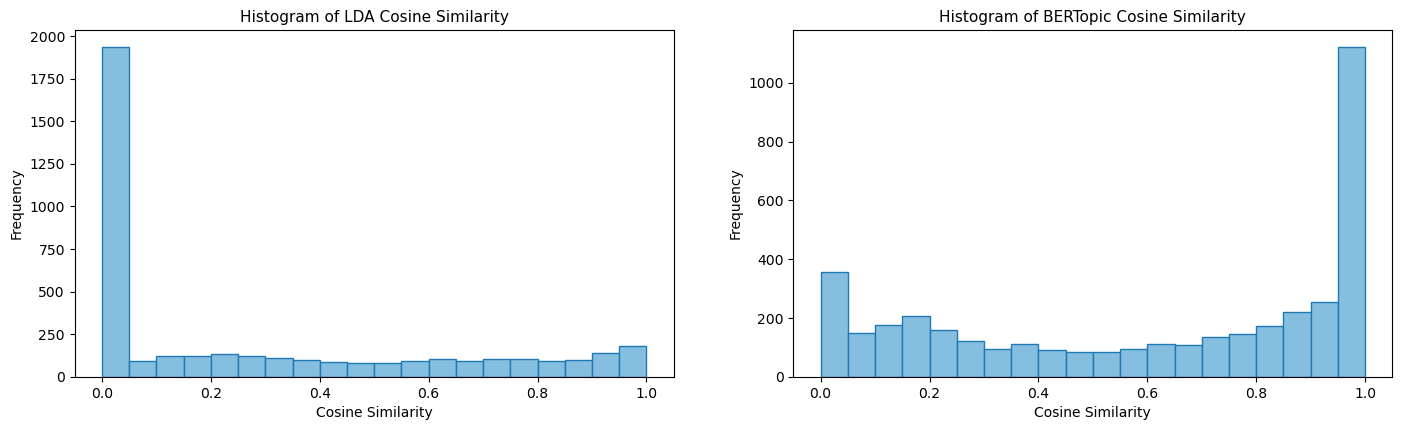

In [21]:
# Histogram
similarities_cols = ["cosine_similarity_lda", "cosine_similarity_BERTopic"]
hist_titles = ["Histogram of LDA Cosine Similarity", "Histogram of BERTopic Cosine Similarity"]

fig, axes = plt.subplots(1, 2, figsize=(17, 4.5))

for ax, col, title in zip(axes, similarities_cols, hist_titles):
    ax.hist(df_data[col], bins=20, edgecolor = "#1e78b4", color= "#86BEE0")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Cosine Similarity")
    ax.set_ylabel("Frequency")

plt.show()

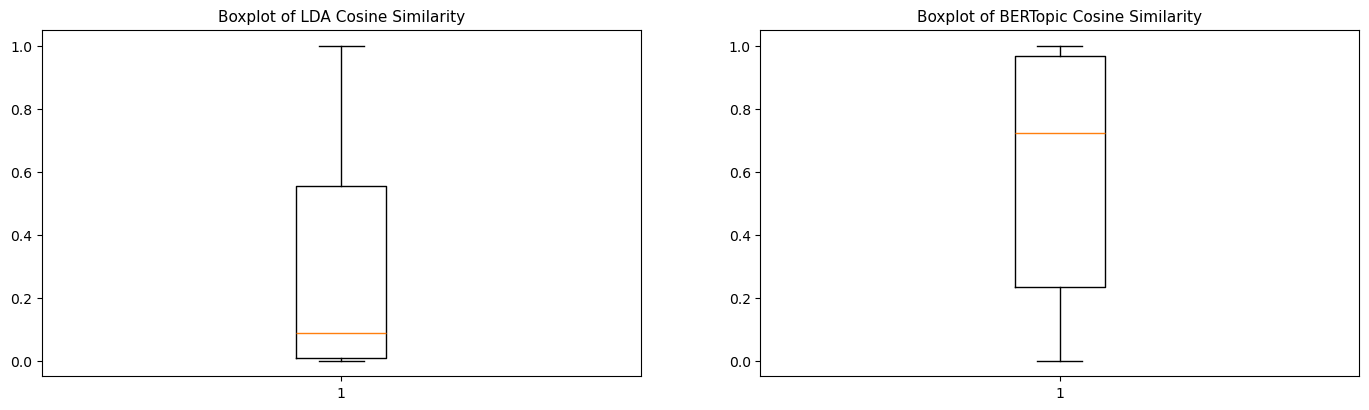

In [22]:
#Boxplot
box_titles = ["Boxplot of LDA Cosine Similarity", "Boxplot of BERTopic Cosine Similarity"]

fig, axes = plt.subplots(1, 2, figsize=(17, 4.5))

for ax, col, title in zip(axes, similarities_cols, box_titles):
    ax.boxplot(df_data[col].dropna(),vert=True)
    ax.set_title(title, fontsize=11)

plt.show()

### Look at correlation - Similarity & Summary Length

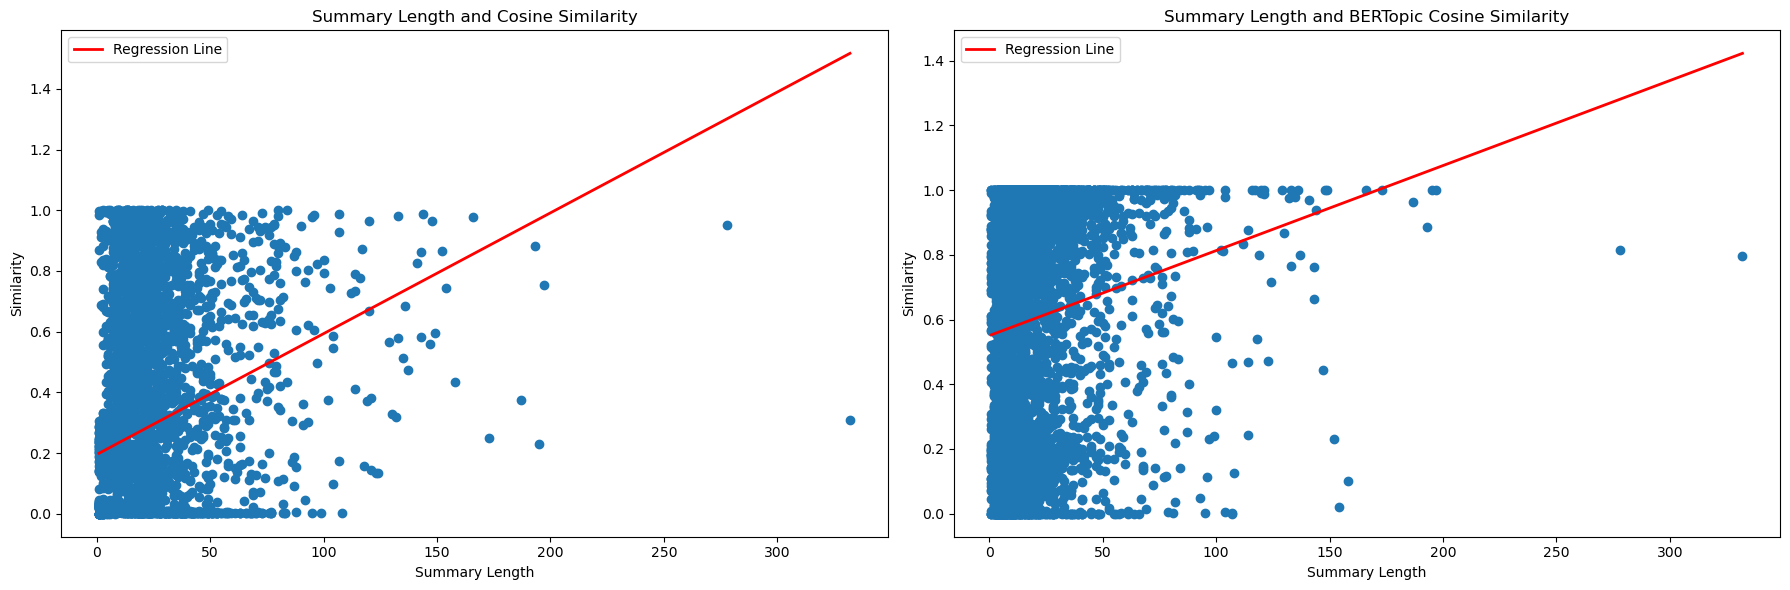

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ---------------- Plot 1 ----------------
model = smf.ols(formula="cosine_similarity_lda ~ summary_length", data=df_data)
results = model.fit()

df_data['Predicted_similarity_lda_2'] = results.fittedvalues

axes[0].scatter(
    df_data["summary_length"],
    df_data["cosine_similarity_lda"]
)

df_plot = df_data.sort_values("summary_length")

axes[0].plot(
    df_plot["summary_length"],
    df_plot["Predicted_similarity_lda_2"],
    color='red',
    label='Regression Line',
    linewidth=2
)

axes[0].set_title('Summary Length and Cosine Similarity')
axes[0].set_xlabel('Summary Length')
axes[0].set_ylabel('Similarity')
axes[0].legend()


# ---------------- Plot 2 ----------------
model = smf.ols(formula="cosine_similarity_BERTopic ~ summary_length", data=df_data)
results = model.fit()

df_data['Predicted_similarity_BERTopic_2'] = results.fittedvalues

axes[1].scatter(
    df_data["summary_length"],
    df_data["cosine_similarity_BERTopic"]
)

df_plot = df_data.sort_values("summary_length")

axes[1].plot(
    df_plot["summary_length"],
    df_plot["Predicted_similarity_BERTopic_2"],
    color='red',
    label='Regression Line',
    linewidth=2
)

axes[1].set_title('Summary Length and BERTopic Cosine Similarity')
axes[1].set_xlabel('Summary Length')
axes[1].set_ylabel('Similarity')
axes[1].legend()

plt.tight_layout()
plt.show()

## Additional Analysis - Subreddit Correlation 

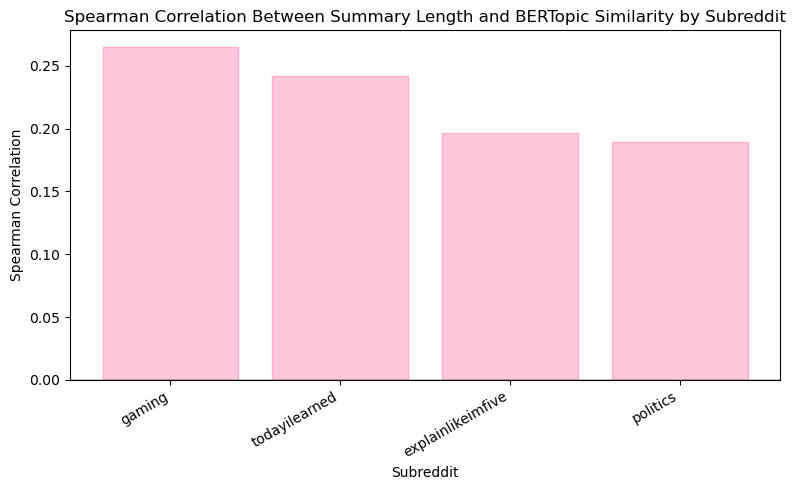

In [24]:
#We wanted to see whether the correlation between the summary length and the similarity differed depending on the subreddit

# First, we calculate Spearman correlation per subreddit since it is less sensitive to outliers
bert_spearman_by_subreddit = (
    df_data
    .groupby("subreddit")
    .apply(
        lambda group: group["cosine_similarity_BERTopic"].corr(
            group["summary_length"],
            method="spearman"
        )
    )
    .reset_index(name="bert_spearman_corr")
)

# For better visual comparison we will sort them... 
bert_spearman_by_subreddit = bert_spearman_by_subreddit.sort_values(
    "bert_spearman_corr",
    ascending=False
)

# ... and then create a bar plot
plt.figure(figsize=(8, 5))

plt.bar(
    bert_spearman_by_subreddit["subreddit"],
    bert_spearman_by_subreddit["bert_spearman_corr"],
    color="#FFC8DD",
    edgecolor="#FFAFCC"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Spearman Correlation Between Summary Length and BERTopic Similarity by Subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Spearman Correlation")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

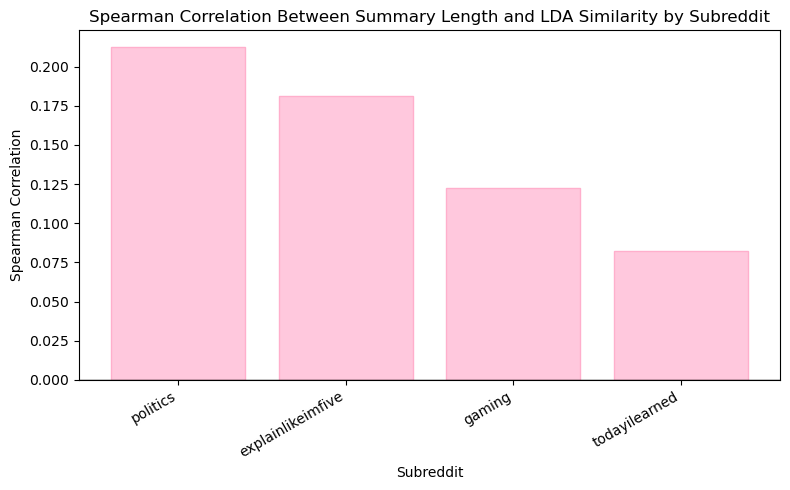

In [27]:
#We wanted to see whether the correlation between the summary length and the similarity differed depending on the subreddit

# First, we calculate Spearman correlation per subreddit since it is less sensitive to outliers
lda_spearman_by_subreddit = (
    df_data
    .groupby("subreddit")
    .apply(
        lambda group: group["cosine_similarity_lda"].corr(
            group["summary_length"],
            method="spearman"
        )
    )
    .reset_index(name="lda_spearman_corr")
)

# For better visual comparison we will sort them... 
lda_spearman_by_subreddit = lda_spearman_by_subreddit.sort_values(
    "lda_spearman_corr",
    ascending=False
)

# ... and then create a bar plot
plt.figure(figsize=(8, 5))

plt.bar(
    lda_spearman_by_subreddit["subreddit"],
    lda_spearman_by_subreddit["lda_spearman_corr"],
    color="#FFC8DD",
    edgecolor="#FFAFCC"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Spearman Correlation Between Summary Length and LDA Similarity by Subreddit")
plt.xlabel("Subreddit")
plt.ylabel("Spearman Correlation")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()